<h1 style="color:#38BDF8; text-align:center; font-weight:bold; border-bottom:3px solid #38BDF8;">Day 4 — Trees, Forests, SVMs &amp; k-NN</h1>
<h3 style="text-align:center; color:#BE185D;">Comparing Classifiers Fairly on the Same Train/Test Split</h3>


<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. Decision Trees</a></li>
<li><a href="#section2">2. Random Forests</a></li>
<li><a href="#section3">3. Support Vector Machines (SVM)</a></li>
<li><a href="#section4">4. k-Nearest Neighbors (k-NN)</a></li>
<li><a href="#section5">5. Comparing Models Fairly</a></li>
<li><a href="#section6">6. Common Mistakes to Avoid</a></li>
<li><a href="#section7">7. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section8">8. Hands-On Lab — Model Comparison</a></li>
<li><a href="#section9">9. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section10">10. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>
<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Days 2 and 3 used one algorithm each (Linear Regression, then Logistic Regression). Today we meet <b>four new classifiers</b> — decision trees, random forests, SVMs, and k-NN — and, more importantly, learn how to compare them <b>fairly</b> on the same data and metric.
</div>


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Pandas version      :", pd.__version__)
print("NumPy version       :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version      : 3.0.2
NumPy version       : 2.4.4
Scikit-learn version: 1.8.0


<a id="section1"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">1. Decision Trees</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 Predicting by asking yes/no questions</h3>
A <b>decision tree</b> predicts by asking a sequence of yes/no questions about the features, splitting the data at each step until it reaches a decision — very similar to how a person might reason through a flowchart ("Is Age &lt; 18? ... Is Fare &gt; $50? ...").

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.2 The strength: you can read the exact rules</h3>
Its great strength is <b>interpretability</b> — unlike logistic regression's coefficients, you can print and read the tree's exact decision rules, step by step.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# model = DecisionTreeClassifier(max_depth=5, random_state=42)
# model.fit(X_train, y_train)

print("We will train a real decision tree in Section 8 (Hands-On Lab).")

We will train a real decision tree in Section 8 (Hands-On Lab).


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <b>The weakness:</b> a decision tree can grow deep enough to <b>memorize</b> the training data — asking increasingly specific questions until every training row has its own leaf. This is called <b>overfitting</b>: perfect on training data, poor on new data. <code>max_depth</code> limits how deep the tree can grow, which helps control this.
</div>


<a id="section2"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">2. Random Forests</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Many trees voting together</h3>
A <b>random forest</b> is an <b>ensemble</b> — instead of training one decision tree, it trains many trees, each on a random subset of the data and features, then lets them <b>vote</b> on the final prediction.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 Why voting fixes overfitting</h3>
This "wisdom of the crowd" is the key idea: any single tree might overfit its particular slice of data, but the <b>errors of many different trees tend to cancel out</b> when averaged together. This makes random forests one of the strongest, most reliable classical models available — often a great default choice for a new problem.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)
# print(model.feature_importances_)   # which features mattered most

print("We will train a real random forest, and inspect its feature importances, in Section 8.")

We will train a real random forest, and inspect its feature importances, in Section 8.


<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> Random forests also report <b>feature importances</b> — a score for each feature showing how much it drove predictions across all the trees. This is valuable both for your own insight into the data and for explaining the model to non-technical stakeholders.
</div>


<a id="section3"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">3. Support Vector Machines (SVM)</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 Finding the widest possible gap</h3>
An <b>SVM</b> finds the decision boundary that <b>maximizes the margin</b> — the widest possible gap between the two classes. Instead of just finding <i>a</i> line that separates the classes, it finds the one with the most breathing room on either side.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.2 The kernel trick — bending the boundary</h3>
With the <b>"kernel trick"</b> an SVM can also draw <b>curved</b> boundaries for data that isn't linearly separable, by implicitly mapping the data into a higher-dimensional space where a straight boundary does exist.

In [ ]:
from sklearn.svm import SVC

# model = SVC(kernel="rbf", probability=True)
# model.fit(X_train, y_train)

print("We will train a real SVM in Section 8.")

We will train a real SVM in Section 8.


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> SVMs are powerful on <b>small-to-medium, high-dimensional</b> datasets (many features, fewer rows) but scale poorly to very large datasets — training time grows quickly as the number of rows increases.
</div>


<a id="section4"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">4. k-Nearest Neighbors (k-NN)</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 The simplest classifier: ask your neighbors</h3>
k-NN is the simplest classifier here: to predict a new point's class, it looks at the <code>k</code> closest training points ("neighbors") and takes a <b>majority vote</b> among them.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.2 No real training happens</h3>
k-NN <b>learns nothing during training</b> — <code>.fit()</code> just stores the data. All the actual work happens at prediction time, when it has to measure distances to every stored training point.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# model = KNeighborsClassifier(n_neighbors=5)
# model.fit(X_train, y_train)

print("We will train a real k-NN classifier in Section 8.")

We will train a real k-NN classifier in Section 8.


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> k-NN is intuitive and effective on small datasets, but it <b>slows down and degrades</b> as data grows in size or in number of dimensions (features) — every prediction has to compare against every stored training point.
</div>


<a id="section5"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">5. Comparing Models Fairly</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.1 No free lunch</h3>
No single algorithm is best for <b>every</b> problem — this is often called the <b>"no free lunch" principle</b>. The professional approach is never to guess which model "should" work best; it is to <b>train several models on the exact same train/test split</b> and compare them fairly on the <b>same metric</b>.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;"><th style="padding:8px; text-align:left;">Model</th><th style="padding:8px; text-align:left;">Strength</th><th style="padding:8px; text-align:left;">Watch Out For</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Decision Tree</td><td style="padding:8px; border-top:1px solid #eee;">Interpretable rules</td><td style="padding:8px; border-top:1px solid #eee;">Overfitting if too deep</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Random Forest</td><td style="padding:8px; border-top:1px solid #eee;">Strong, reliable default</td><td style="padding:8px; border-top:1px solid #eee;">Less interpretable than one tree</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">SVM</td><td style="padding:8px; border-top:1px solid #eee;">Powerful in high dimensions</td><td style="padding:8px; border-top:1px solid #eee;">Slow on large datasets</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">k-NN</td><td style="padding:8px; border-top:1px solid #eee;">Simple, intuitive</td><td style="padding:8px; border-top:1px solid #eee;">Slow and weaker as data grows</td></tr>
</table>
</div>


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> "Fair comparison" means the <b>same</b> <code>X_train</code>/<code>X_test</code>/<code>y_train</code>/<code>y_test</code> split, the same <code>random_state</code>, and the same evaluation metric for every model — exactly what we will do in the Hands-On Lab.
</div>


<a id="section6"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">6. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <ul>
<li><b>Comparing models on different splits</b> — always reuse the exact same <code>train_test_split()</code> output for every model being compared.</li>
<li><b>Letting a decision tree grow unlimited depth</b> — set <code>max_depth</code> or it will likely overfit.</li>
<li><b>Forgetting that k-NN and SVM are distance-based</b> — features on very different scales (e.g. Age vs. Fare) can distort distance calculations; scaling (Day 5) fixes this.</li>
<li><b>Picking a "winner" from accuracy alone</b> — apply the same precision/recall/F1/AUC lens from Day 3 when comparing classifiers.</li>
<li><b>Assuming random forest always wins</b> — it is a strong default, not a guarantee; that is exactly why we compare instead of assuming.</li>
</ul>
</div>


<a id="section7"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">7. Quick Reference</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Decision tree</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.tree import DecisionTreeClassifier</code><br><code>DecisionTreeClassifier(max_depth=5, random_state=42)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Random forest</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.ensemble import RandomForestClassifier</code><br><code>RandomForestClassifier(n_estimators=100, random_state=42)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">SVM</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.svm import SVC</code><br><code>SVC(kernel="rbf", probability=True)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">k-NN</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.neighbors import KNeighborsClassifier</code><br><code>KNeighborsClassifier(n_neighbors=5)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Feature importances</td><td style="padding:8px; border-top:1px solid #eee;"><code>model.feature_importances_</code> (trees &amp; forests only)</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Fit any of them</td><td style="padding:8px; border-top:1px solid #eee;"><code>model.fit(X_train, y_train)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Compare with F1</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.metrics import f1_score</code><br><code>f1_score(y_test, predictions)</code></td></tr>
</table>
</div>


<a id="section8"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">8. Hands-On Lab — Model Comparison</h2>
<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f;">
<b>Goal:</b> Train a decision tree, random forest, SVM, and k-NN on the <b>same Titanic train/test split</b> used on Day 3, evaluate all four fairly on the same metric, and decide which one wins — and why.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">8.0 Loading the dataset and recreating Day 3's split</h3>
We reuse <code>train_and_test2.csv</code>, the same Titanic passenger dataset from Day 3, with the same features and the same <code>random_state=42</code> split — so every model in this lab is judged on identical training and test data.

In [ ]:
from sklearn.model_selection import train_test_split

titanic = pd.read_csv("train_and_test2.csv")
titanic = titanic.rename(columns={"2urvived": "Survived"})

features = ["Age", "Fare", "Sex", "sibsp", "Parch", "Pclass"]
X = titanic[features]
y = titanic["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])

Training rows: 1047 | Test rows: 262


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Train a decision tree, random forest, SVM, and k-NN on the same split</h3>


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name:<15} trained.")

Decision Tree   trained.


Random Forest   trained.
SVM             trained.
k-NN            trained.


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Evaluate all four with the same metric and assemble one comparison table</h3>


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, model in models.items():
    predictions = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, predictions), 3),
        "Precision": round(precision_score(y_test, predictions), 3),
        "Recall": round(recall_score(y_test, predictions), 3),
        "F1-score": round(f1_score(y_test, predictions), 3),
    })

comparison_table = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
comparison_table

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.760,0.589,0.452,0.512
1,Random Forest,0.710,0.480,0.493,0.486
2,k-NN,0.729,0.522,0.329,0.403
3,SVM,0.733,0.714,0.068,0.125


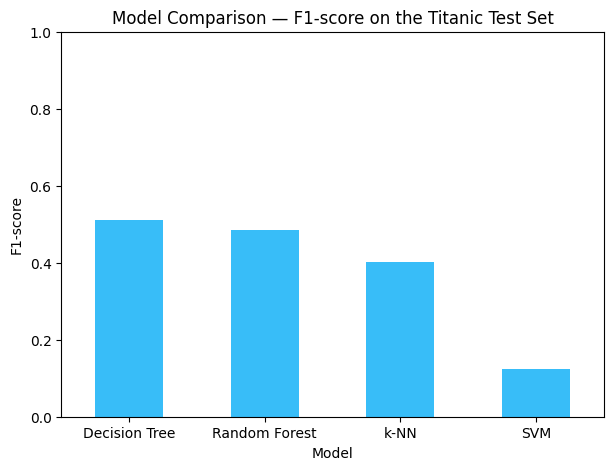

In [ ]:
comparison_table.plot(x="Model", y="F1-score", kind="bar", legend=False,
                      color="#38BDF8", figsize=(7, 5))
plt.title("Model Comparison — F1-score on the Titanic Test Set")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Report the random forest's top feature importances and interpret them</h3>


Feature importances (highest to lowest):
Fare      0.360619
Age       0.334323
Sex       0.147252
Pclass    0.062494
sibsp     0.051416
Parch     0.043897
dtype: float64


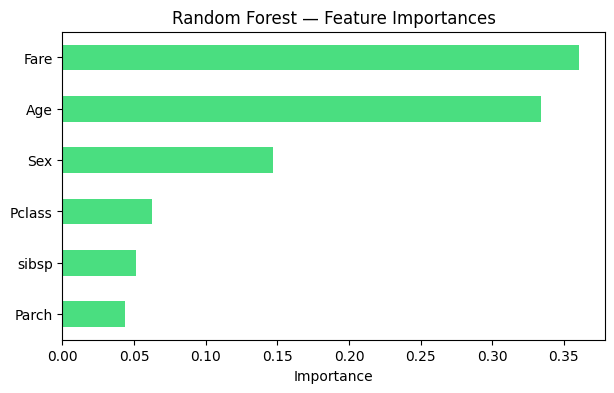

In [ ]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

print("Feature importances (highest to lowest):")
print(importances)

importances.plot(kind="barh", figsize=(7, 4), color="#4ADE80")
plt.title("Random Forest — Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

<div style="border-left:5px solid #4ADE80; background-color:#eafff2;
padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">

<b>Interpretation:</b>
Fare, Age, and Sex were the three most important features in the Random Forest.
This means that the model relied on them more heavily when separating survivors
from non-survivors. Feature importance indicates predictive influence, but it
does not prove causation.

</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Identify the best-performing model and explain why it likely won</h3>


In [ ]:
best_model_name = comparison_table.iloc[0]["Model"]
best_f1 = comparison_table.iloc[0]["F1-score"]
print(f"Best-performing model by F1-score: {best_model_name} (F1 = {best_f1})")
comparison_table

Best-performing model by F1-score: Decision Tree (F1 = 0.512)


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.760,0.589,0.452,0.512
1,Random Forest,0.710,0.480,0.493,0.486
2,k-NN,0.729,0.522,0.329,0.403
3,SVM,0.733,0.714,0.068,0.125


<div style="border-left:5px solid #BE185D; background-color:#fff0f6;
padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">

<b>Model Comparison Conclusion:</b>
The Decision Tree achieved the highest F1-score of <b>0.512</b> on this
test set. It likely performed well because its rule-based splits captured useful
nonlinear relationships between the passenger features and survival.
However, this result applies only to the current dataset and train/test split;
it does not mean that Decision Trees are always the best model.

</div>

<a id="section9"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">9. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <ul>
<li>Always compare models on the <b>exact same</b> train/test split and <code>random_state</code>.</li>
<li>Use the <b>same metric</b> for every model in a comparison — mixing metrics makes the comparison meaningless.</li>
<li>Limit decision tree depth (<code>max_depth</code>) to reduce overfitting risk.</li>
<li>Remember that SVM and k-NN are <b>distance-based</b> — feature scaling (Day 5) often improves them significantly.</li>
<li>Never assume one algorithm is "best" without testing it on <i>this</i> specific dataset.</li>
</ul>
</div>


<a id="section10"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">10. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> <ul>
<li><b>Decision trees</b> ask a sequence of yes/no questions — interpretable, but prone to overfitting if grown too deep.</li>
<li><b>Random forests</b> are ensembles of many trees voting together — usually stronger and more reliable than a single tree.</li>
<li><b>SVMs</b> find the decision boundary with the widest margin — powerful in high dimensions, slow on very large datasets.</li>
<li><b>k-NN</b> classifies by majority vote among the nearest training points — simple, but slows down and weakens as data grows.</li>
<li><b>No single algorithm wins every problem</b> — always compare multiple models fairly, on the same split and the same metric, before picking one.</li>
<li>Today's comparison workflow connects directly to <b>Day 5</b>, where we build a complete end-to-end pipeline — EDA, preprocessing, modeling, and evaluation — as a full mini-project.</li>
</ul>
</div>
